### Title : Design and implement Deep Convolutional GAN to generate images of faces/digits from a set of given images.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, LeakyReLU, Reshape
from keras.datasets import fashion_mnist


#### Load Dataset

In [ ]:
(train_x, _), (_, _) = fashion_mnist.load_data()
train_x = train_x / 255.0
train_x = train_x.reshape(-1,28,28,1)
train_x = train_x * 2 - 1
print(train_x.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


#### Generator

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape, Input

generator = Sequential([
    Input(shape=(100,)),   # ✅ correct way

    Dense(512),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),   # ✅ FIXED

    Dense(256),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),

    Dense(128),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),

    Dense(784, activation='tanh'),  # GAN standard
    Reshape((28, 28, 1))
])

generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,656 (1.22 MB)

 Trainable params: 318,864 (1.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

#### Discriminator

In [ ]:
discriminator = Sequential([
 Flatten(input_shape=(28,28,1)),
 Dense(256),
 LeakyReLU(0.2),
 Dropout(0.5),
 Dense(128),
 LeakyReLU(0.2),
 Dropout(0.5),
 Dense(64),
 LeakyReLU(0.2),
 Dropout(0.5),
 Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,177 (946.00 KB)

 Trainable params: 242,177 (946.00 KB)

 Non-trainable params: 0 (0.00 B)

#### GAN Model

In [ ]:
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')
gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       320,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │       242,177 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,833 (2.15 MB)

 Trainable params: 318,864 (1.22 MB)

 Non-trainable params: 243,969 (953.00 KB)

#### Training

Epoch 1


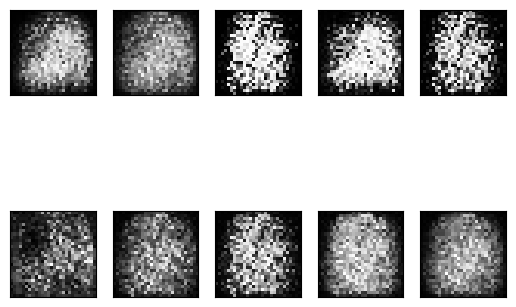

Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Training complete


In [ ]:
epochs=10
batch_size=100
noise_dim=100

for epoch in range(epochs):
 print(f"Epoch {epoch+1}")
 for i in range(train_x.shape[0]//batch_size):
  noise = np.random.normal(0,1,(batch_size,noise_dim))
  fake = generator.predict(noise, verbose=0)
  real = train_x[i*batch_size:(i+1)*batch_size]

  y_real = np.ones((batch_size,1))
  y_fake = np.zeros((batch_size,1))

  discriminator.trainable=True
  discriminator.train_on_batch(real,y_real)
  discriminator.train_on_batch(fake,y_fake)

  noise = np.random.normal(0,1,(batch_size,noise_dim))
  discriminator.trainable=False
  gan.train_on_batch(noise,y_real)

 if epoch%10==0:
  samples=10
  gen = generator.predict(np.random.normal(0,1,(samples,noise_dim)), verbose=0)
  for k in range(samples):
   plt.subplot(2,5,k+1)
   plt.imshow(gen[k].reshape(28,28), cmap='gray')
   plt.xticks([]); plt.yticks([])
  plt.show()

print('Training complete')

#### Final Output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


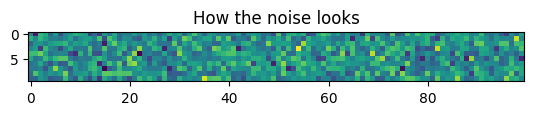

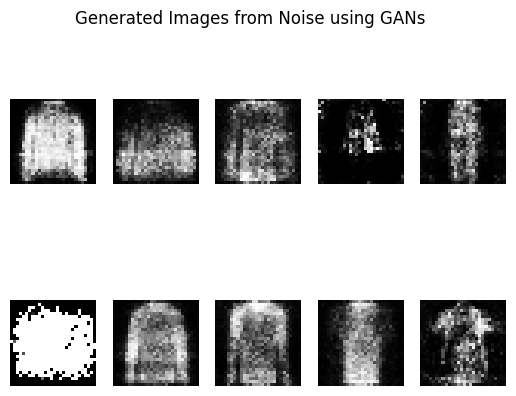

In [ ]:
noise = np.random.normal(0,1,(10,100))
gen = generator.predict(noise)

plt.imshow(noise)
plt.title('How the noise looks')
plt.show()

fig, ax = plt.subplots(2,5)
fig.suptitle('Generated Images from Noise using GANs')
idx=0
for i in range(2):
 for j in range(5):
  ax[i,j].imshow(gen[idx].reshape(28,28), cmap='gray')
  ax[i,j].axis('off')
  idx+=1
plt.show()